# The Quartic Anharmonic Oscillator Propagator via Spectral Decomposition

This notebook computes the real-time quantum propagator
$$K(x_b, t \mid x_a, 0) = \langle x_b \mid e^{-iHt/\hbar} \mid x_a \rangle$$
for the one-dimensional quartic anharmonic oscillator with Hamiltonian
$$H = \frac{p^2}{2m} + \tfrac{1}{2} m \omega^2 x^2 + \tfrac{1}{4} \lambda x^4.$$

We work in units $m = \omega = \hbar = 1$ throughout. The coupling $\lambda \geq 0$ is the only free parameter.

**Method.** The spectral decomposition
$$K(x_b, t \mid x_a, 0) = \sum_n \psi_n(x_a)\, \psi_n(x_b)\, e^{-i E_n t / \hbar}$$
is exact. We compute the $E_n$ and $\psi_n$ by diagonalising $H$ in a truncated harmonic-oscillator basis of size $N$. The only error is from basis truncation, which is exponentially small in $N$.

**Outline.**
1. Build the Hamiltonian matrix.
2. Diagonalise; check convergence.
3. Reconstruct eigenfunctions on a spatial grid.
4. Assemble the propagator.
5. Sanity checks: composition, Euclidean diagonalisation, $\langle x^2 \rangle_\beta$, parity, harmonic limit.
6. Tables of $K$ for varying $\lambda$ at multiple endpoints.
7. Plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

np.set_printoptions(precision=10, suppress=False, linewidth=130)

## 1. Hamiltonian Matrix

In the HO basis, $x = (a + a^\dagger)/\sqrt{2}$ is tridiagonal. We compute $x^4 = (x^2)^2$ by matrix multiplication, then
$$H_{mn} = (n + \tfrac{1}{2})\,\delta_{mn} + \tfrac{\lambda}{4}\,(x^4)_{mn}.$$

In [2]:
def build_hamiltonian(N, lam):
    """Returns (H, x_matrix) in HO basis of size N."""
    n = np.arange(N)
    x_mat = np.zeros((N, N))
    s = np.sqrt(n[1:]) / np.sqrt(2)
    x_mat[np.arange(N-1), np.arange(1, N)] = s
    x_mat[np.arange(1, N), np.arange(N-1)] = s
    x2 = x_mat @ x_mat
    x4 = x2 @ x2
    H = np.diag(n + 0.5) + 0.25 * lam * x4
    return H, x_mat

# Check: lambda=0 gives 0.5, 1.5, ...
H0, _ = build_hamiltonian(50, 0.0)
print("lambda=0 eigenvalues:", eigh(H0, eigvals_only=True)[:6])

lambda=0 eigenvalues: [0.5 1.5 2.5 3.5 4.5 5.5]


## 2. Diagonalisation and Convergence

With our convention at $\lambda=1$: $E_0 = 0.6209270298\ldots$

**Convention warning:** papers use $\lambda x^4$, $\lambda x^4/4$, $g x^4$, etc. Always check.

In [3]:
for N in [20, 40, 80, 160, 320]:
    H, _ = build_hamiltonian(N, 1.0)
    print(f"N={N:4d}:  E_0 = {eigh(H, eigvals_only=True)[0]:.14f}")
print("Reference: 0.6209270298...")

N=  20:  E_0 = 0.62092699478146
N=  40:  E_0 = 0.62092702982572
N=  80:  E_0 = 0.62092702982575
N= 160:  E_0 = 0.62092702982575
N= 320:  E_0 = 0.62092702982575
Reference: 0.6209270298...


In [4]:
N_BASIS = 400

def diagonalise(lam, N=N_BASIS):
    H, x_mat = build_hamiltonian(N, lam)
    evals, evecs = eigh(H)
    return evals, evecs, x_mat

## 3. Eigenfunctions on a Grid

Stable three-term recurrence for normalised HO wavefunctions:
$$\phi_0 = \pi^{-1/4} e^{-x^2/2},\quad \phi_1 = \sqrt{2}\,x\,\phi_0,\quad \phi_n = \sqrt{\tfrac{2}{n}}\,x\,\phi_{n-1} - \sqrt{\tfrac{n-1}{n}}\,\phi_{n-2}.$$
True eigenfunctions: $\psi_n(x) = \sum_m C_{mn}\,\phi_m(x)$.

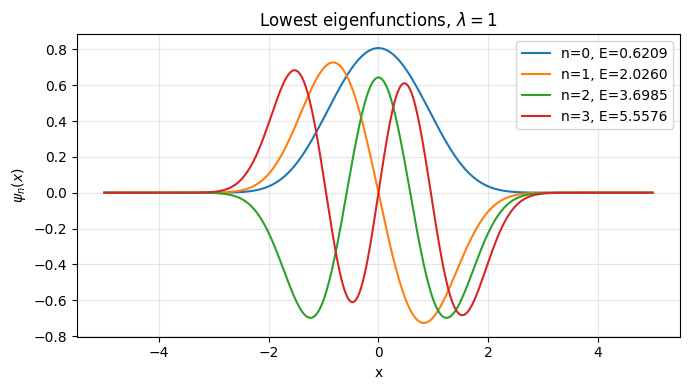

In [5]:
def ho_basis(N, x):
    Phi = np.zeros((N, len(x)))
    Phi[0] = np.pi**(-0.25) * np.exp(-0.5*x**2)
    if N > 1:
        Phi[1] = np.sqrt(2.0)*x*Phi[0]
    for n in range(2, N):
        Phi[n] = np.sqrt(2.0/n)*x*Phi[n-1] - np.sqrt((n-1.0)/n)*Phi[n-2]
    return Phi

def eigenfunctions(C, x):
    return C.T @ ho_basis(C.shape[0], x)

# Plot
xg = np.linspace(-5, 5, 401)
ev, C, _ = diagonalise(1.0)
Psi = eigenfunctions(C, xg)
plt.figure(figsize=(7, 4))
for n in range(4):
    plt.plot(xg, Psi[n], label=f"n={n}, E={ev[n]:.4f}")
plt.xlabel("x"); plt.ylabel(r"$\psi_n(x)$")
plt.title(r"Lowest eigenfunctions, $\lambda=1$")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. The Propagator

**Real time:** $K(x_b,t|x_a,0) = \sum_n \psi_n(x_a)\psi_n(x_b)e^{-iE_n t}.$

**Euclidean** ($t \to -i\beta$): $K_E(x_b,\beta|x_a,0) = \sum_n \psi_n(x_a)\psi_n(x_b)e^{-\beta E_n}.$ This is real, symmetric, positive.

In [6]:
def propagator(lam, xa, xb, t, N=N_BASIS):
    xa = np.atleast_1d(np.asarray(xa, float))
    xb = np.atleast_1d(np.asarray(xb, float))
    ev, C, _ = diagonalise(lam, N)
    Pa, Pb = eigenfunctions(C, xa), eigenfunctions(C, xb)
    K = np.einsum("ni,nj,n->ij", Pa, Pb, np.exp(-1j*ev*t))
    return K.item() if K.size == 1 else K

def euclidean_prop(lam, xa, xb, beta, N=N_BASIS):
    xa = np.atleast_1d(np.asarray(xa, float))
    xb = np.atleast_1d(np.asarray(xb, float))
    ev, C, _ = diagonalise(lam, N)
    Pa, Pb = eigenfunctions(C, xa), eigenfunctions(C, xb)
    K = np.einsum("ni,nj,n->ij", Pa, Pb, np.exp(-beta*ev))
    return K.item() if K.size == 1 else K

K_test = propagator(1.0, 0.5, 0.7, 1.0)
print(f"K(0.7, t=1 | 0.5, 0) at lam=1: {K_test}")
print(f"|K| = {abs(K_test):.10f}")

K(0.7, t=1 | 0.5, 0) at lam=1: (0.556214229186513-0.3953105035804645j)
|K| = 0.6823816110


## 5. Sanity Checks

---

### 5.1 Composition (semigroup)

$$K(x, x''; t_1+t_2) = \int dx'\; K(x, x'; t_1)\,K(x', x''; t_2).$$
The integral is done numerically on a grid; residual error $\sim O(\Delta x^2)$.

In [7]:
def test_composition(lam, xa=0.4, xb=0.6, t1=0.5, t2=0.7,
                     x_max=8.0, n_grid=4001):
    xi = np.linspace(-x_max, x_max, n_grid)
    dx = xi[1] - xi[0]
    K1 = propagator(lam, xa, xi, t1)[0]
    K2 = propagator(lam, xi, xb, t2)[:, 0]
    K_comp = np.sum(K2 * K1) * dx
    K_dir  = propagator(lam, xa, xb, t1 + t2)
    print(f"  lam={lam:6.1f}:  |diff| = {abs(K_dir - K_comp):.3e}")

print("=== Test 1: Composition ===")
for lam in [1.0, 10.0, 50.0, 100.0]:
    test_composition(lam)

=== Test 1: Composition ===
  lam=   1.0:  |diff| = 4.565e-03
  lam=  10.0:  |diff| = 2.492e-03
  lam=  50.0:  |diff| = 8.825e-04
  lam= 100.0:  |diff| = 7.350e-03


### 5.2 Diagonalise $K_E$ as a matrix

Build $K_E(x_i, x_j; \beta)$ on a spatial grid. In the continuum,
$$\int dx'\, K_E(x, x'; \beta)\, \psi_n(x') = e^{-\beta E_n}\, \psi_n(x).$$
Discretised: the eigenvalues of $\mathbf{K}_E \cdot \Delta x$ should be $e^{-\beta E_n}$. We extract energies as $E_n = -\ln(\mathrm{eigenvalue})/\beta$ and compare to the $E_n$ from diagonalising $H$ directly.

In [8]:
def test_euclidean_diag(lam, beta=2.0, x_max=6.0, n_grid=301, n_show=6):
    x = np.linspace(-x_max, x_max, n_grid)
    dx = x[1] - x[0]
    K_mat = euclidean_prop(lam, x, x, beta)
    eig_K = np.sort(np.linalg.eigvalsh(K_mat * dx))[::-1]
    evals_H, _, _ = diagonalise(lam)
    ref = np.exp(-beta * evals_H[:n_show])

    print(f"  lam={lam}, beta={beta}")
    print(f"  {'n':>3}  {'exp(-bE) [H]':>22}  {'eig [K_E]':>22}  {'|diff|':>10}")
    print(f"  " + "-"*60)
    for n in range(n_show):
        print(f"  {n:3d}  {ref[n]:>22.14e}  {eig_K[n]:>22.14e}  {abs(ref[n]-eig_K[n]):>10.2e}")

print("=== Test 2: Euclidean diagonalisation ===")
test_euclidean_diag(lam=1.0)
print()
test_euclidean_diag(lam=10.0)

=== Test 2: Euclidean diagonalisation ===
  lam=1.0, beta=2.0
    n            exp(-bE) [H]               eig [K_E]      |diff|
  ------------------------------------------------------------
    0    2.88848179414045e-01    2.88848179414045e-01    1.11e-16
    1    1.73887413971113e-02    1.73887413971114e-02    5.90e-17
    2    6.13150193142332e-04    6.13150193142332e-04    6.51e-19
    3    1.48850340327488e-05    1.48850340327500e-05    1.18e-18
    4    2.66778863816692e-07    2.66778863816069e-07    6.23e-19
    5    3.68757877342543e-09    3.68757877511486e-09    1.69e-18

  lam=10.0, beta=2.0
    n            exp(-bE) [H]               eig [K_E]      |diff|
  ------------------------------------------------------------
    0    1.32875769741073e-01    1.32875769741073e-01    1.39e-16
    1    8.99673007352957e-04    8.99673007352963e-04    6.72e-18
    2    1.41592091660791e-06    1.41592091660804e-06    1.35e-19
    3    9.13290647565741e-10    9.13290647713068e-10    1.47e-1

### 5.3 Thermal $\langle x^2 \rangle_\beta$

$$\langle x^2 \rangle_\beta = \frac{\mathrm{Tr}(x^2 e^{-\beta H})}{\mathrm{Tr}(e^{-\beta H})} = \frac{\sum_n \langle n|x^2|n\rangle e^{-\beta E_n}}{\sum_n e^{-\beta E_n}}.$$

**Method A** (from $K_E$ diagonal on a grid):
$$\langle x^2 \rangle_\beta = \frac{\sum_i x_i^2\, K_E(x_i, x_i; \beta)\, \Delta x}{\sum_i K_E(x_i, x_i; \beta)\, \Delta x}.$$

**Method B** (from spectrum): rotate $x^2$ to energy eigenbasis, $\langle n|x^2|n\rangle = (C^T x^2 C)_{nn}$, then weight by Boltzmann factors.

Agreement = confidence that both the Euclidean propagator and the spectral quantities are correct.

In [9]:
def test_x2(lam, beta=1.0, x_max=8.0, n_grid=2001):
    x = np.linspace(-x_max, x_max, n_grid)
    dx = x[1] - x[0]
    # Method A: full K_E matrix, extract diagonal
    K_mat = euclidean_prop(lam, x, x, beta)
    K_diag = np.diag(K_mat)
    x2_K = np.sum(x**2 * K_diag * dx) / np.sum(K_diag * dx)

    # Method B: from spectrum
    ev, C, x_mat = diagonalise(lam)
    x2_eig = np.diag(C.T @ (x_mat @ x_mat) @ C)
    b = np.exp(-beta * ev)
    x2_spec = np.sum(x2_eig * b) / np.sum(b)

    print(f"  lam={lam:6.1f}:  from K_E = {x2_K:.12f}   "
          f"from spectrum = {x2_spec:.12f}   |diff| = {abs(x2_K - x2_spec):.2e}")

print("=== Test 3: Thermal <x^2> ===")
for lam in [0.1, 1.0, 10.0, 100.0]:
    test_x2(lam)

=== Test 3: Thermal <x^2> ===
  lam=   0.1:  from K_E = 0.885333278381   from spectrum = 0.885333278381   |diff| = 3.33e-16
  lam=   1.0:  from K_E = 0.513415118279   from spectrum = 0.513415118279   |diff| = 0.00e+00
  lam=  10.0:  from K_E = 0.223717696444   from spectrum = 0.223717696444   |diff| = 3.89e-16
  lam= 100.0:  from K_E = 0.097777489674   from spectrum = 0.097777489674   |diff| = 2.22e-16


### 5.4 Parity and harmonic limit

In [15]:
def mehler(xa, xb, t):
    """Closed-form HO propagator (m=omega=hbar=1)."""
    return (np.sqrt(1/(2j*np.pi*np.sin(t)))
            * np.exp(1j/(2*np.sin(t))*((xa**2+xb**2)*np.cos(t)-2*xa*xb)))

print("=== Parity ===")
for lam in [0.1, 1.0, 50.0]:
    Kp = propagator(lam, 0.7, 1.3, 2.0)
    Kn = propagator(lam, -0.7, -1.3, 2.0)
    print(f"  lam={lam:5.1f}:  |K(x)-K(-x)| = {abs(Kp-Kn):.3e}")

print("\n=== Harmonic limit ===")
for lam in [1e-2, 1e-4, 1e-6]:
    K_num = propagator(lam, 0, 0, 1)
    K_ho  = mehler(0, 0, 1)
    diff  = abs(K_num - K_ho)
    print(f"  lam={lam:.0e}")
    print(f"    K_num (spectral): Re={K_num.real:+.12f}, Im={K_num.imag:+.12f}")
    print(f"    K_HO  (Mehler)  : Re={K_ho.real:+.12f},  Im={K_ho.imag:+.12f}")
    print(f"    |K_num - K_HO|  = {diff:.3e}")

=== Parity ===
  lam=  0.1:  |K(x)-K(-x)| = 3.872e-14
  lam=  1.0:  |K(x)-K(-x)| = 1.687e-12
  lam= 50.0:  |K(x)-K(-x)| = 6.168e-11

=== Harmonic limit ===
  lam=1e-02
    K_num (spectral): Re=+0.307095290114, Im=-0.303034566927
    K_HO  (Mehler)  : Re=+0.307521507728,  Im=-0.307521507728
    |K_num - K_HO|  = 4.507e-03
  lam=1e-04
    K_num (spectral): Re=+0.311241785590, Im=-0.311824289741
    K_HO  (Mehler)  : Re=+0.307521507728,  Im=-0.307521507728
    |K_num - K_HO|  = 5.688e-03
  lam=1e-06
    K_num (spectral): Re=+0.301108497895, Im=-0.318669836353
    K_HO  (Mehler)  : Re=+0.307521507728,  Im=-0.307521507728
    |K_num - K_HO|  = 1.286e-02


---

## 6. Tables: $K$ for Varying $\lambda$ at Multiple Endpoints

Three endpoint choices at $t = 1$:

| Set | $x_a$ | $x_b$ | Why |
|-----|-------|-------|-----|
| **A** | 0.5 | 0.7 | Generic; all eigenstates contribute. |
| **B** | 0 | 0 | Only even-$n$ contribute ($\psi_\text{odd}(0) = 0$). |
| **C** | 0.5 | 0 | Mixed; all $n$ enter but with $\psi_n(0)$ filtering. |

In [11]:
t_ref = 1.0
lam_list = [0.0, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0, 100.0]
endpoints = [(0.5, 0.7, "A: xa=0.5, xb=0.7"),
             (0.0, 0.0, "B: xa=0,   xb=0"),
             (0.5, 0.0, "C: xa=0.5, xb=0")]

for xa, xb, label in endpoints:
    print(f"\n{'='*82}")
    print(f"  {label}    t={t_ref}    (m=omega=hbar=1, N={N_BASIS})")
    print(f"{'='*82}")
    print(f"{'lambda':>10}  {'Re K':>18}  {'Im K':>18}  {'|K|':>18}")
    print("-"*70)
    for lam in lam_list:
        K = propagator(lam, xa, xb, t_ref)
        print(f"{lam:>10.4f}  {K.real:>+18.12f}  {K.imag:>+18.12f}  {abs(K):>18.12f}")


  A: xa=0.5, xb=0.7    t=1.0    (m=omega=hbar=1, N=400)
    lambda                Re K                Im K                 |K|
----------------------------------------------------------------------
    0.0000     +0.237198508144     -0.357742088560      0.429234824068
    0.0100     +0.254021548964     -0.361768693084      0.442044720174
    0.1000     -0.115722699968     -0.497794248071      0.511068348365
    0.5000     -0.720199754869     +0.074221428135      0.724014162366
    1.0000     +0.556214229187     -0.395310503580      0.682381610970
    2.0000     -0.169744911041     -0.684304230570      0.705042987910
    5.0000     -0.956442906421     -0.205932649969      0.978361533160
   10.0000     -0.230352005930     -1.167025516073      1.189542181599
   25.0000     -0.055310939763     -0.260723820167      0.266526190945
   50.0000     +1.650540162113     +0.166436542297      1.658910470568
  100.0000     +0.805712236301     -3.006191963612      3.112292134394

  B: xa=0,   xb=0  

## 7. Plots

### 7.1 $|K|$ vs $\lambda$ for all three endpoint sets

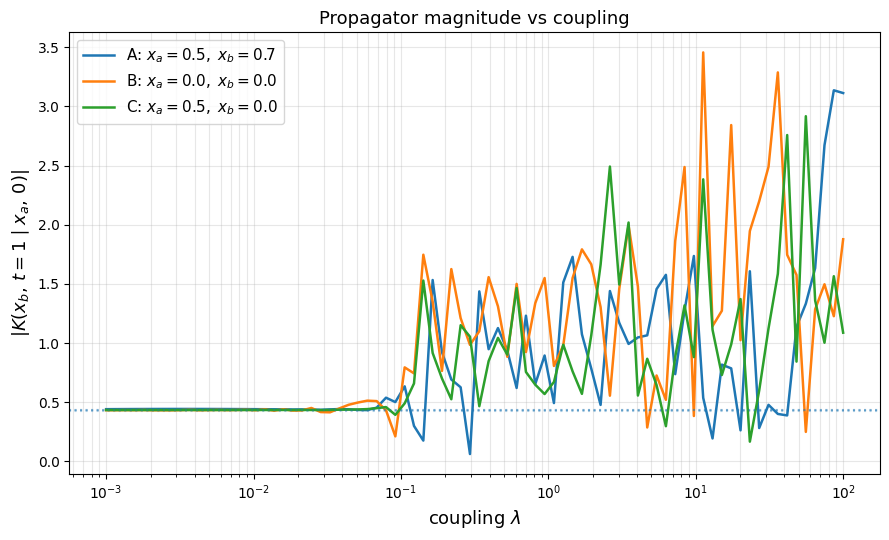

In [12]:
lam_plot = np.concatenate([np.array([0.0]), np.logspace(-3, 2, 80)])

fig, ax = plt.subplots(figsize=(9, 5.5))
for xa, xb, label in endpoints:
    absK = np.array([abs(propagator(lam, xa, xb, t_ref)) for lam in lam_plot])
    tag = label.split(":")[0].strip()
    ax.plot(lam_plot[1:], absK[1:], "-", lw=1.8,
            label=f"{tag}: $x_a={xa},\; x_b={xb}$")
    ax.axhline(absK[0], ls=":", alpha=0.35)
ax.set_xscale("log")
ax.set_xlabel(r"coupling $\lambda$", fontsize=13)
ax.set_ylabel(r"$|K(x_b,\, t{=}1 \mid x_a,\, 0)|$", fontsize=13)
ax.set_title(r"Propagator magnitude vs coupling", fontsize=13)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

### 7.2 $K$ as a function of $x_b$ for several $\lambda$, at $x_a = 0.5$ and $x_a = 0$

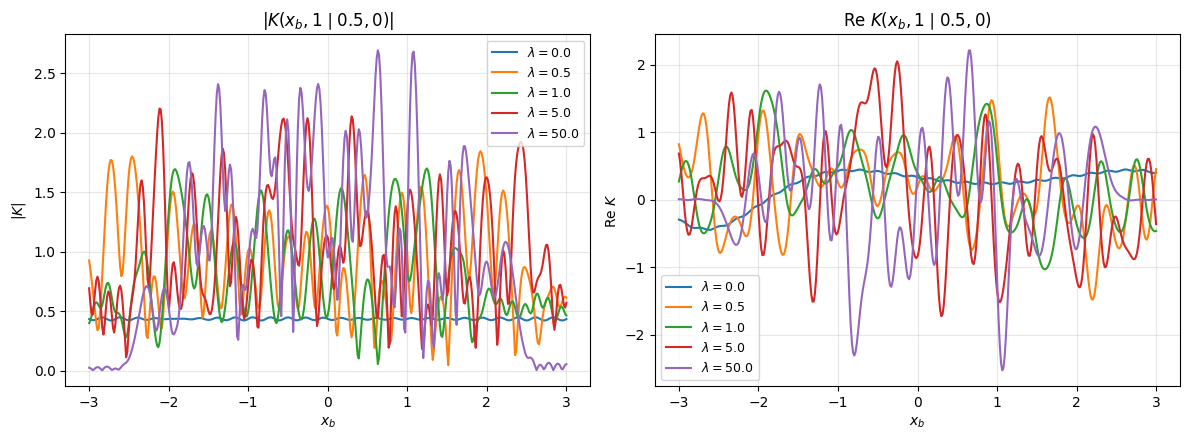

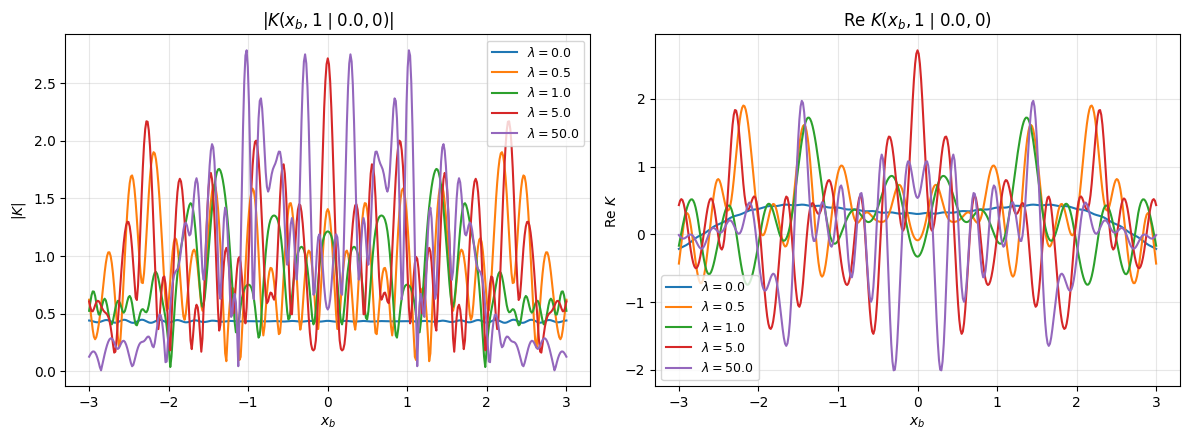

In [13]:
xb_g = np.linspace(-3, 3, 401)

for xa_fix in [0.5, 0.0]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for lam in [0.0, 0.5, 1.0, 5.0, 50.0]:
        Kl = propagator(lam, xa_fix, xb_g, t_ref)[0]
        axes[0].plot(xb_g, np.abs(Kl), label=f"$\\lambda={lam}$")
        axes[1].plot(xb_g, np.real(Kl), label=f"$\\lambda={lam}$")
    for ax in axes:
        ax.set_xlabel(r"$x_b$"); ax.grid(alpha=0.3); ax.legend(fontsize=9)
    axes[0].set_ylabel(r"$|K|$")
    axes[0].set_title(fr"$|K(x_b,1 \mid {xa_fix},0)|$")
    axes[1].set_ylabel(r"Re $K$")
    axes[1].set_title(fr"Re $K(x_b,1 \mid {xa_fix},0)$")
    plt.tight_layout(); plt.show()

## Summary

| # | Sanity check | What it catches |
|---|-------------|----------------|
| 1 | Composition: $K(t_1{+}t_2) = \int K(t_1)K(t_2)\,dx'$ | Wrong eigenvalues or eigenfunctions |
| 2 | Diagonalise $K_E$ matrix → eigenvalues $= e^{-\beta E_n}$ | Wavefunction errors; grid artefacts |
| 3 | $\langle x^2 \rangle_\beta$ from $K_E$ diagonal vs from spectrum | Errors in $K_E$ or in the $x^2$ matrix |
| 4 | Parity: $K(-x_b \mid -x_a) = K(x_b \mid x_a)$ | Symmetry violations |
| 5 | Harmonic limit: $K \to K_\mathrm{HO}$ as $\lambda \to 0$ | Convention errors; normalisation |

**For ML benchmarking:** pick $(x_a, x_b, t, \lambda)$, get reference $K$ from this notebook, compare. If there is disagreement, the *kind* of sanity-check failure tells you what is broken.

**Validity:** $\lambda \leq 100$ with $N=400$ gives machine precision for low-lying states. For $\lambda \gg 100$, use a scaled basis.